In [1]:
# Supervise Learning 
## 1. Import Necessary Libraries
## 2. Load and Explore the dataset
## 3. Splitting Data into Training and Test Sets
## 4. Data Preprocessing
## 5. Model Fitting, Test, Evaluation  
## 6. Evaluation models

In [2]:
# Unsupervised learning steps for KMeans Clustering 
# Step 1: Import libraries
# Step 2: Load, explore, and visualize the data.
# Step 3: Drop the features that are not relevant, make noise  
# Step 4: Data Preprocessing or Normalize the data for clustering.
# Step 5: Dimensionality Reduction: Apply PCA or other techniques to reduce the dimension dataset. 
# Step 6: Use the Elbow Method to find the optimal number of clusters.
# Step 7: Apply KMeans with the selected number of clusters.
# Step 8: Assign cluster labels to data.
# Step 9: Evaluate the clustering using metrics Silhouette Score 
# Step 10: Visualize the clusters and their centroids, perform KMeans clustering, and evaluate its performance.
# Step 11: Interpret Results: Analyze the clusters to understand their characteristics and identify patterns.
# Step 12: Refine clustering by experimenting with linkage methods or algorithms.

KMeans Clustering
KMeans is a clustering algorithm that partitions data into a predefined number of clusters by minimizing within-cluster variance.

Steps:

Initialization: Randomly select 'k' centroids.

Assignment: Assign each point to the nearest centroid.

Update: Recalculate centroids as the mean of assigned points.

Iteration: Repeat steps 2 and 3 until centroids stabilize.

Key Points:

Requires specifying 'k' clusters.

Works best with spherical, similarly-sized clusters.

Sensitive to initial centroid placement; need to multiple runs. 

Efficient for large datasets.

Evaluation:

Use Silhouette Score to assess cluster quality.

The Elbow Method helps find the optimal number of clusters by analyzing within-cluster variance.

## 1. Import Necessary Libraries

In [3]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from ydata_profiling import ProfileReport
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA



## 2. Load, Explore and Initial Visualization data

In [4]:
df = pd.read_csv("C:\\Users\\Dell\\Desktop\\AAA 2024\\2024 Python Data Science\\Machine Learning\\earthquake_data.csv")

In [5]:
print(df.head())
print(df.info())

                                          title  magnitude         date_time  \
0  M 7.0 - 18 km SW of Malango, Solomon Islands        7.0  22-11-2022 02:03   
1      M 6.9 - 204 km SW of Bengkulu, Indonesia        6.9  18-11-2022 13:37   
2                                      M 7.0 -         7.0  12-11-2022 07:09   
3           M 7.3 - 205 km ESE of Neiafu, Tonga        7.3  11-11-2022 10:48   
4                                      M 6.6 -         6.6  09-11-2022 10:14   

   cdi  mmi  alert  tsunami  sig net  nst   dmin   gap magType    depth  \
0    8    7  green        1  768  us  117  0.509  17.0     mww   14.000   
1    4    4  green        0  735  us   99  2.229  34.0     mww   25.000   
2    3    3  green        1  755  us  147  3.125  18.0     mww  579.000   
3    5    5  green        1  833  us  149  1.865  21.0     mww   37.000   
4    0    2  green        1  670  us  131  4.998  27.0     mww  624.464   

   latitude  longitude                  location continent          

Earthquake dataset

Datasets contain records of 782 earthquakes from 1/1/2001 to 1/1/2023. The meaning of all columns is as follows:

title: title name given to the earthquake

magnitude: The magnitude of the earthquake

date_time: date and time

cdi: The maximum reported intensity for the event range

mmi: The maximum estimated instrumental intensity for the event

alert: The alert level - “green”, “yellow”, “orange”, and “red”

tsunami: "1" for events in oceanic regions and "0" otherwise

sig: A number describing how significant the event is. Larger numbers indicate a more significant event. This value is determined on a number of factors, including: magnitude, maximum MMI, felt reports, and estimated impact

net: The ID of a data contributor. Identifies the network considered to be the preferred source of information for this event.

nst: The total number of seismic stations used to determine earthquake location.

dmin: Horizontal distance from the epicenter to the nearest station

gap: The largest azimuthal gap between azimuthally adjacent stations (in degrees). In general, the smaller this number, the more reliable is the calculated horizontal position of the earthquake. Earthquake locations in which the azimuthal gap exceeds 180 degrees typically have large location and depth uncertainties

magType: The method or algorithm used to calculate the preferred magnitude for the event

depth: The depth where the earthquake begins to rupture

latitude / longitude: coordinate system by means of which the position or location of any place on Earth's surface can be determined and described

location: location within the country

continent: continent of the earthquake hit country

country: affected country

title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert        367
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       5
continent    576
country      298
dtype: int64


<Axes: >

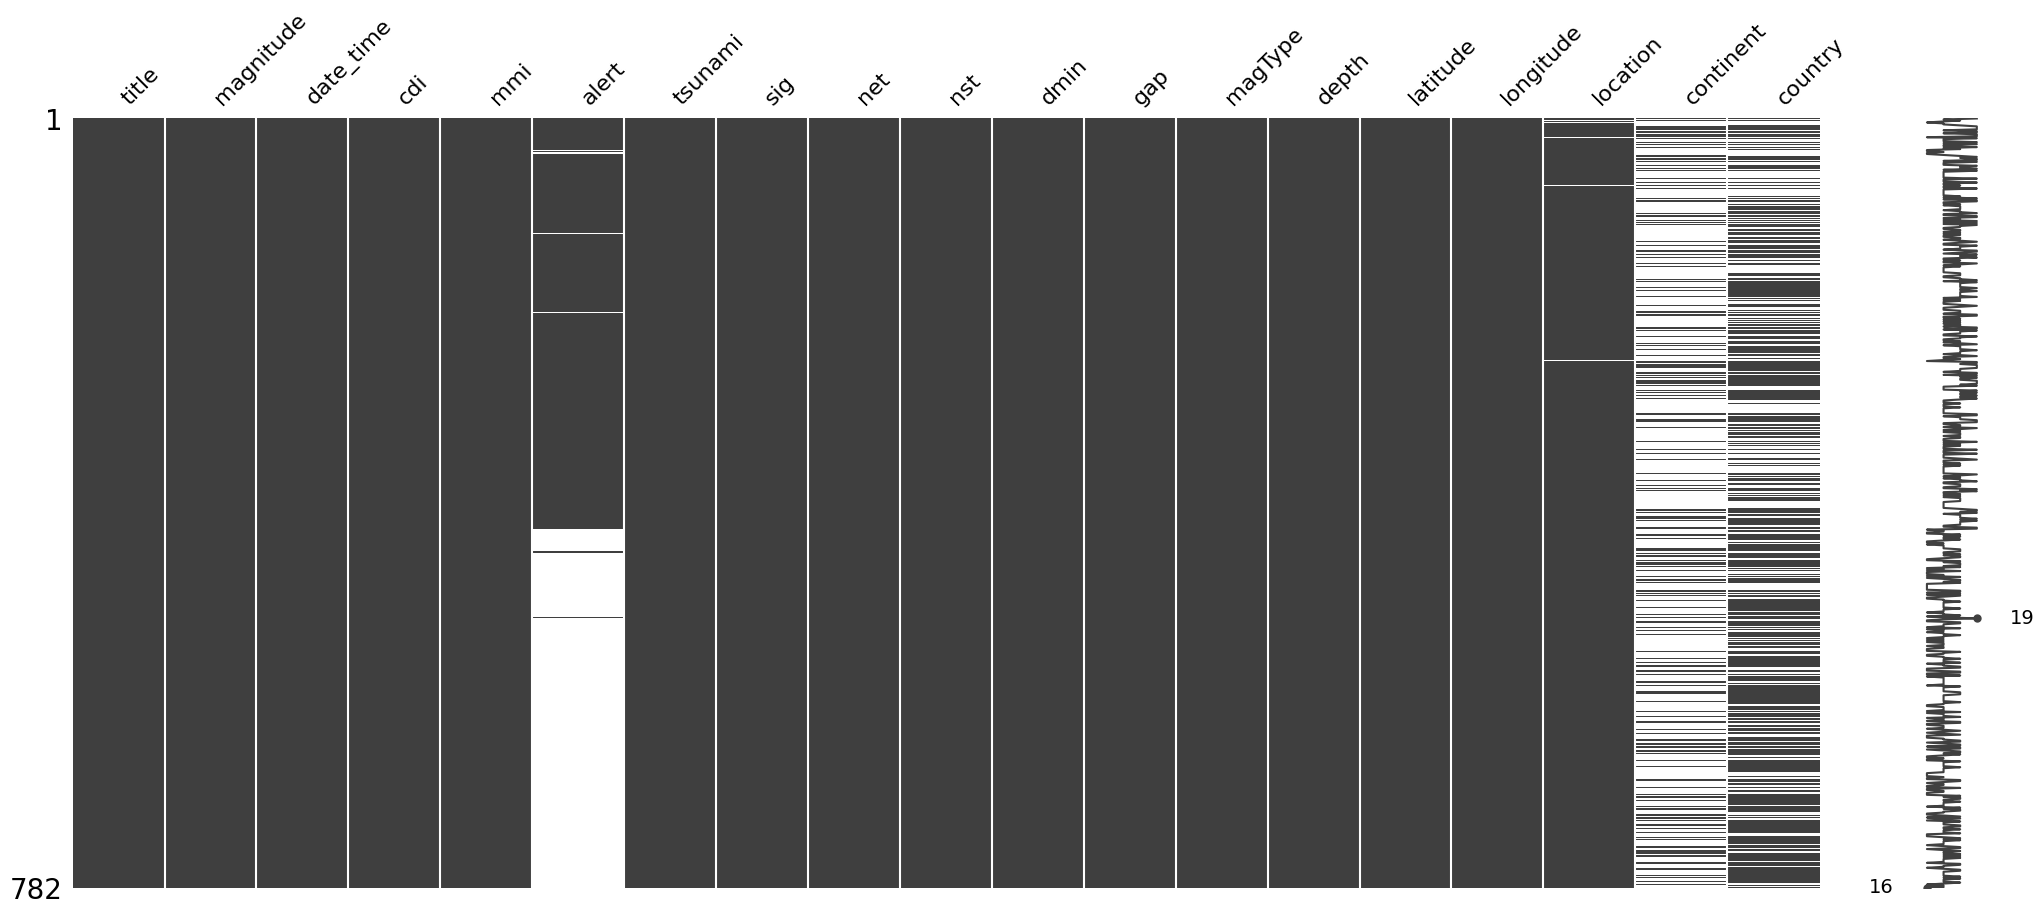

In [6]:
missing_counts = df.isnull().sum()
print(missing_counts)
msno.matrix(df)

In [7]:
print(df.duplicated().sum())

0


In [8]:
print((df == 0).sum())

title          0
magnitude      0
date_time      0
cdi          212
mmi            0
alert          0
tsunami      478
sig            0
net            0
nst          365
dmin         405
gap           70
magType        0
depth          0
latitude       0
longitude      0
location       0
continent      0
country        0
dtype: int64


In [9]:
print("Columns with exactly 2 unique values:")
for col in df.columns:
    unique_values = df[col].dropna().unique()  
    if len(unique_values) == 2:
        print(f"Column '{col}':")
        print(df[col].value_counts())

Columns with exactly 2 unique values:
Column 'tsunami':
tsunami
0    478
1    304
Name: count, dtype: int64


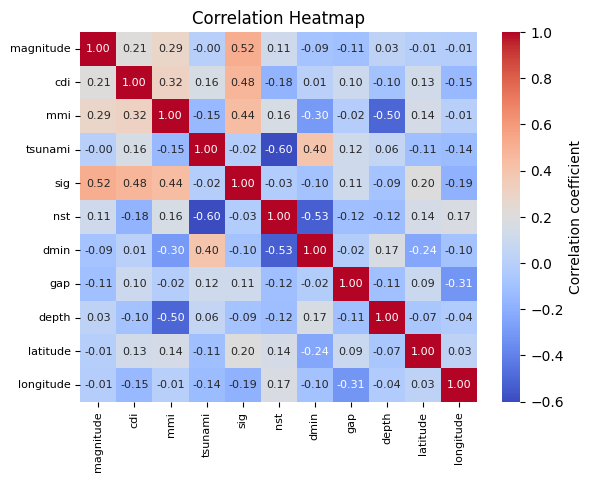

In [10]:
numeric_data = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_data.corr(), annot=True, 
             cmap="coolwarm", fmt=".2f", annot_kws={"size": 8}, 
             cbar_kws={'label': 'Correlation coefficient'})
plt.title("Correlation Heatmap")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

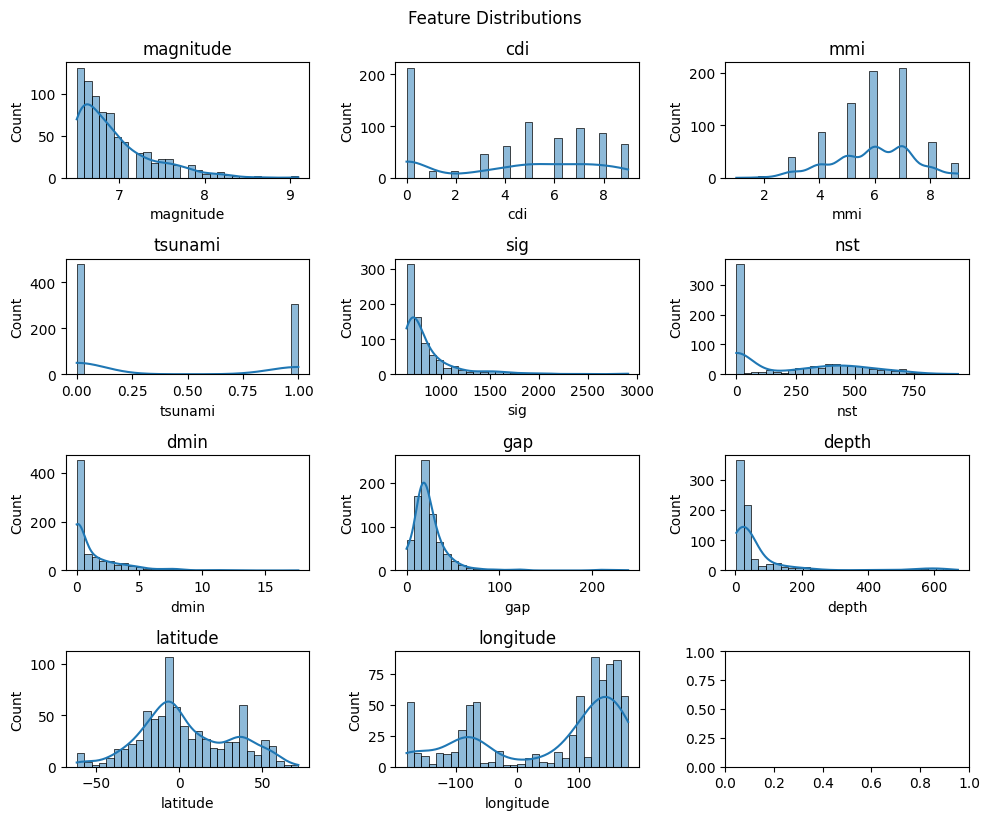

In [11]:
# Feature Distributions:
numeric_columns = df.select_dtypes(include=['number']).columns
fig, axes = plt.subplots(4, 3, figsize=(10, 8))
axes = axes.flatten()
for i, column in enumerate(numeric_columns):
    sns.histplot(data=df, x=column, kde=True, bins=30, ax=axes[i])  
    axes[i].set_title(f'{column}')  
plt.tight_layout()
plt.suptitle("Feature Distributions", y=1.02)  
plt.show()

In [12]:
# Skewness and kurtosis help evaluate the distribution of numerical features
# Skewness close to 0 suggests a symmetric distribution, 
# positive skew (>0) indicates a right tail,  
# negative skew (<0) indicates a left tail.

# Kurtosis values around 3 indicate a normal distribution. 
# Values > 3 suggest heavy tails (outliers), 
# while < 3 suggests light tails.

print("Skewness for numerical columns:")
print(df.select_dtypes(include=['number']).skew())

print("Kurtosis for numerical columns:")
print(df.select_dtypes(include=['number']).kurt())

Skewness for numerical columns:
magnitude    1.444440
cdi         -0.197310
mmi         -0.250403
tsunami      0.457333
sig          3.083629
nst          0.533307
dmin         2.604580
gap          4.668607
depth        3.024869
latitude     0.200853
longitude   -0.702982
dtype: float64
Kurtosis for numerical columns:
magnitude     2.226391
cdi          -1.357753
mmi          -0.224592
tsunami      -1.795445
sig          12.000754
nst          -1.092793
dmin          9.283367
gap          32.027722
depth         8.384480
latitude     -0.476740
longitude    -1.088383
dtype: float64


Number of outliers in each column: 
magnitude     37
cdi            0
mmi            1
tsunami        0
sig           73
nst            0
dmin          61
gap           48
depth        139
latitude       0
longitude      0
dtype: int64


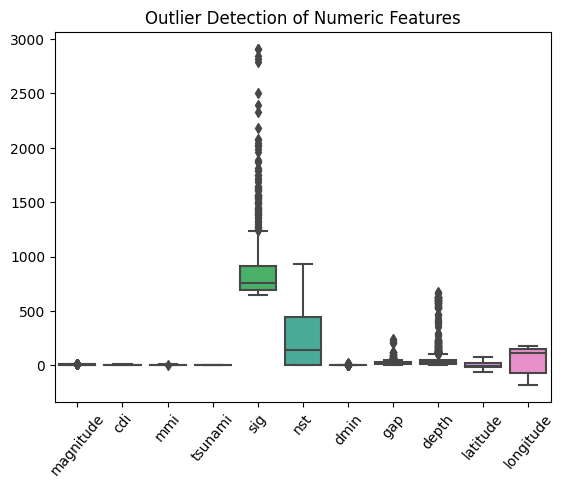

In [13]:
# Outlier Detection 
numeric_df = df.select_dtypes(include=['float64', 'int64'])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).sum()
print(f"Number of outliers in each column: \n{outliers}")

sns.boxplot(data=numeric_df)
plt.title("Outlier Detection of Numeric Features")
plt.xticks(rotation=50)
plt.show()

In [14]:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')
print(df['date_time'].head())

0   2022-11-22 02:03:00
1   2022-11-18 13:37:00
2   2022-11-12 07:09:00
3   2022-11-11 10:48:00
4   2022-11-09 10:14:00
Name: date_time, dtype: datetime64[ns]


In [15]:
# removing spaces, converting to lowercase for object columns
object_columns = df.select_dtypes(include=['object']).columns
for column in object_columns:
    df[column] = df[column].str.strip().str.replace(' ', '').str.lower()
print(df.head())

                                 title  magnitude           date_time  cdi  \
0  m7.0-18kmswofmalango,solomonislands        7.0 2022-11-22 02:03:00    8   
1     m6.9-204kmswofbengkulu,indonesia        6.9 2022-11-18 13:37:00    4   
2                                m7.0-        7.0 2022-11-12 07:09:00    3   
3          m7.3-205kmeseofneiafu,tonga        7.3 2022-11-11 10:48:00    5   
4                                m6.6-        6.6 2022-11-09 10:14:00    0   

   mmi  alert  tsunami  sig net  nst   dmin   gap magType    depth  latitude  \
0    7  green        1  768  us  117  0.509  17.0     mww   14.000   -9.7963   
1    4  green        0  735  us   99  2.229  34.0     mww   25.000   -4.9559   
2    3  green        1  755  us  147  3.125  18.0     mww  579.000  -20.0508   
3    5  green        1  833  us  149  1.865  21.0     mww   37.000  -19.2918   
4    2  green        1  670  us  131  4.998  27.0     mww  624.464  -25.5948   

   longitude                location continent    

In [16]:
# Group columns by their data types
for dtype in df.dtypes.unique():
    print(f"\n{dtype} columns:")
    print(df.select_dtypes(include=[dtype]).columns.tolist())


object columns:
['title', 'alert', 'net', 'magType', 'location', 'continent', 'country']

float64 columns:
['magnitude', 'dmin', 'gap', 'depth', 'latitude', 'longitude']

datetime64[ns] columns:
['date_time']

int64 columns:
['cdi', 'mmi', 'tsunami', 'sig', 'nst']


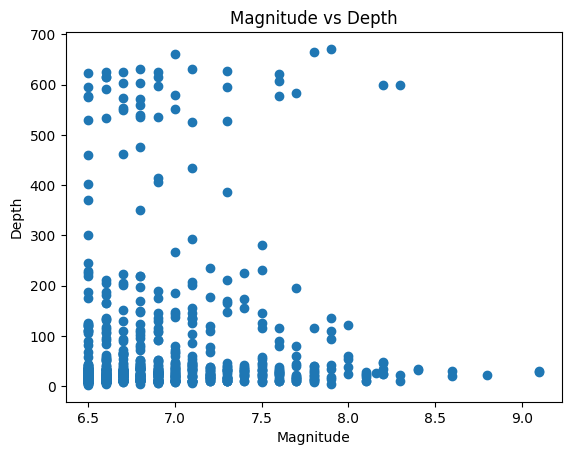

In [17]:
# Visualizing numerical features
plt.scatter(df['magnitude'], df['depth'])
plt.xlabel('Magnitude')
plt.ylabel('Depth')
plt.title('Magnitude vs Depth')
plt.show()

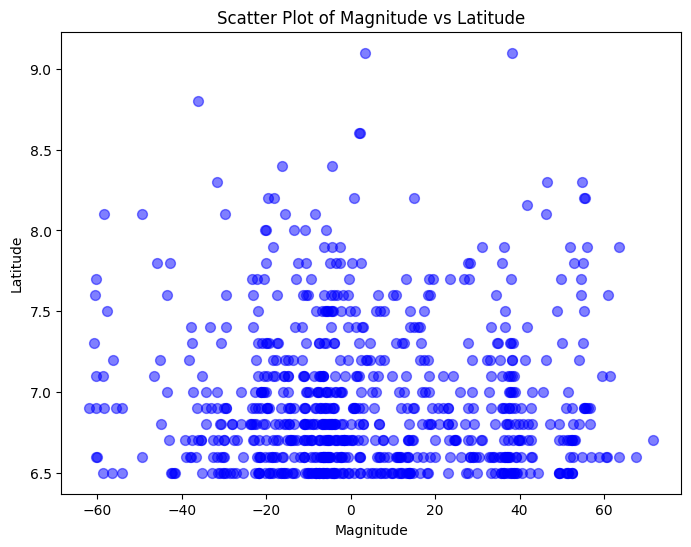

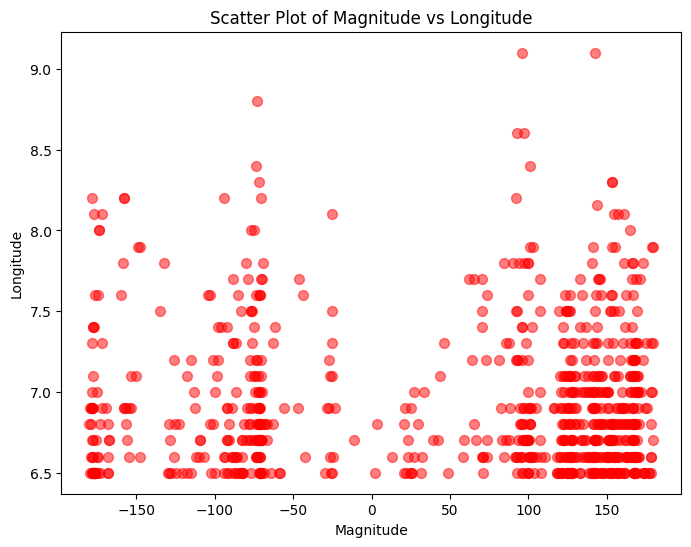

In [18]:
# Scatter plot of Magnitude vs Latitude
plt.figure(figsize=(8, 6))
plt.scatter(df['latitude'], df['magnitude'], s=50, color='blue', alpha=0.5)
plt.ylabel('Latitude')
plt.xlabel('Magnitude')
plt.title('Scatter Plot of Magnitude vs Latitude')
plt.show()

# Scatter plot of Magnitude vs Longitude
plt.figure(figsize=(8, 6))
plt.scatter(df['longitude'], df['magnitude'], s=50, color='red', alpha=0.5)
plt.ylabel('Longitude')
plt.xlabel('Magnitude')
plt.title('Scatter Plot of Magnitude vs Longitude')
plt.show()


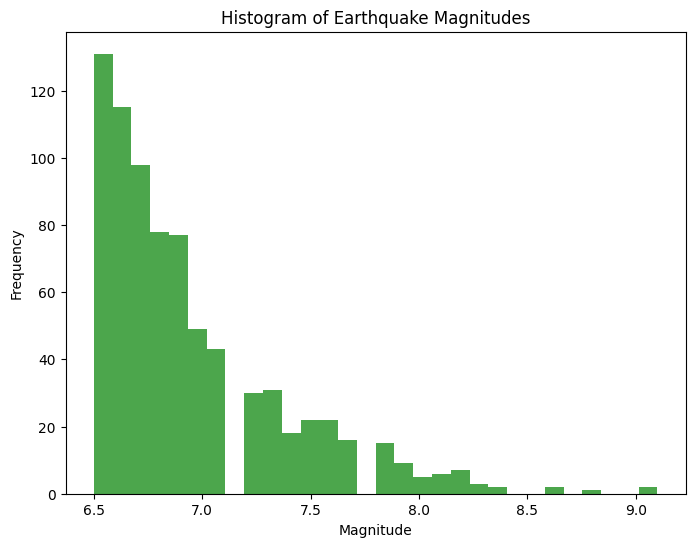

In [19]:
# Histogram of earthquake magnitudes
plt.figure(figsize=(8, 6))
plt.hist(df['magnitude'], bins=30, color='green', alpha=0.7)
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.title('Histogram of Earthquake Magnitudes')
plt.show()


## 3. Drop Feature not relevant 

In [20]:
drop_columns = ['title', 'location', 'net', 'date_time', 'country']
data = df.drop(columns=drop_columns)  
print(f"data: {data.shape}")
print(data.head())
print(data.dtypes)

data: (782, 14)
   magnitude  cdi  mmi  alert  tsunami  sig  nst   dmin   gap magType  \
0        7.0    8    7  green        1  768  117  0.509  17.0     mww   
1        6.9    4    4  green        0  735   99  2.229  34.0     mww   
2        7.0    3    3  green        1  755  147  3.125  18.0     mww   
3        7.3    5    5  green        1  833  149  1.865  21.0     mww   
4        6.6    0    2  green        1  670  131  4.998  27.0     mww   

     depth  latitude  longitude continent  
0   14.000   -9.7963    159.596   oceania  
1   25.000   -4.9559    100.738       NaN  
2  579.000  -20.0508   -178.346   oceania  
3   37.000  -19.2918   -172.129       NaN  
4  624.464  -25.5948    178.278       NaN  
magnitude    float64
cdi            int64
mmi            int64
alert         object
tsunami        int64
sig            int64
nst            int64
dmin         float64
gap          float64
magType       object
depth        float64
latitude     float64
longitude    float64
continen

## 4. Data Preprocessing

In [21]:
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_imputer = SimpleImputer(strategy='median')
data[numerical_columns] = numerical_imputer.fit_transform(data[numerical_columns])
print(f"Preprocessed Data:\n{data.head()}")

Preprocessed Data:
   magnitude  cdi  mmi  alert  tsunami    sig    nst   dmin   gap magType  \
0        7.0  8.0  7.0  green      1.0  768.0  117.0  0.509  17.0     mww   
1        6.9  4.0  4.0  green      0.0  735.0   99.0  2.229  34.0     mww   
2        7.0  3.0  3.0  green      1.0  755.0  147.0  3.125  18.0     mww   
3        7.3  5.0  5.0  green      1.0  833.0  149.0  1.865  21.0     mww   
4        6.6  0.0  2.0  green      1.0  670.0  131.0  4.998  27.0     mww   

     depth  latitude  longitude continent  
0   14.000   -9.7963    159.596   oceania  
1   25.000   -4.9559    100.738       NaN  
2  579.000  -20.0508   -178.346   oceania  
3   37.000  -19.2918   -172.129       NaN  
4  624.464  -25.5948    178.278       NaN  


In [22]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_columns:
    cap_outliers(data, col)
print(f"Preprocessed Data:\n{data.head()}")

Preprocessed Data:
   magnitude  cdi  mmi  alert  tsunami    sig    nst    dmin   gap magType  \
0        7.0  8.0  7.0  green      1.0  768.0  117.0  0.5090  17.0     mww   
1        6.9  4.0  4.0  green      0.0  735.0   99.0  2.2290  34.0     mww   
2        7.0  3.0  3.0  green      1.0  755.0  147.0  3.1250  18.0     mww   
3        7.3  5.0  5.0  green      1.0  833.0  149.0  1.8650  21.0     mww   
4        6.6  0.0  2.0  green      1.0  670.0  131.0  4.6575  27.0     mww   

     depth  latitude  longitude continent  
0   14.000   -9.7963    159.596   oceania  
1   25.000   -4.9559    100.738       NaN  
2  103.375  -20.0508   -178.346   oceania  
3   37.000  -19.2918   -172.129       NaN  
4  103.375  -25.5948    178.278       NaN  


In [23]:
scaler_robust = RobustScaler()
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
data[numerical_columns] = scaler_robust.fit_transform(data[numerical_columns])
print(f"Preprocessed Data:\n{data.head()}")

Preprocessed Data:
   magnitude       cdi  mmi  alert  tsunami       sig       nst      dmin  \
0        0.4  0.428571  0.5  green      1.0  0.064000 -0.051685  0.273215   
1        0.2 -0.142857 -1.0  green      0.0 -0.086857 -0.092135  1.196457   
2        0.4 -0.285714 -1.5  green      1.0  0.004571  0.015730  1.677402   
3        1.0  0.000000 -0.5  green      1.0  0.361143  0.020225  1.001074   
4       -0.4 -0.714286 -2.0  green      1.0 -0.384000 -0.020225  2.500000   

        gap magType     depth  latitude  longitude continent  
0 -0.195122     mww -0.343916 -0.184045   0.227416   oceania  
1  0.910569     mww -0.036224 -0.060723  -0.039382       NaN  
2 -0.130081     mww  2.156084 -0.445306  -1.304443   oceania  
3  0.065041     mww  0.299441 -0.425968  -1.276262       NaN  
4  0.455285     mww  2.156084 -0.586554   0.312100       NaN  


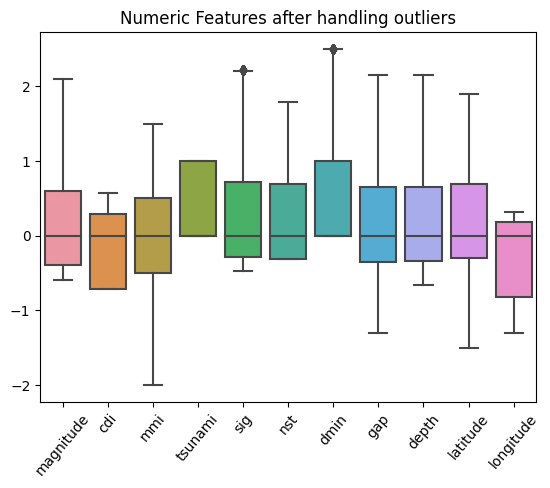

In [24]:
sns.boxplot(data=data[numerical_columns])
plt.title("Numeric Features after handling outliers")
plt.xticks(rotation=50)
plt.show()

In [25]:
object_columns = data.select_dtypes(include=['object']).columns.tolist()
object_imputer = SimpleImputer(strategy='most_frequent')
data[object_columns] = object_imputer.fit_transform(data[object_columns])
print(data[object_columns].isnull().sum())
print(f"Preprocessed Data set:\n{data.head()}")

alert        0
magType      0
continent    0
dtype: int64
Preprocessed Data set:
   magnitude       cdi  mmi  alert  tsunami       sig       nst      dmin  \
0        0.4  0.428571  0.5  green      1.0  0.064000 -0.051685  0.273215   
1        0.2 -0.142857 -1.0  green      0.0 -0.086857 -0.092135  1.196457   
2        0.4 -0.285714 -1.5  green      1.0  0.004571  0.015730  1.677402   
3        1.0  0.000000 -0.5  green      1.0  0.361143  0.020225  1.001074   
4       -0.4 -0.714286 -2.0  green      1.0 -0.384000 -0.020225  2.500000   

        gap magType     depth  latitude  longitude continent  
0 -0.195122     mww -0.343916 -0.184045   0.227416   oceania  
1  0.910569     mww -0.036224 -0.060723  -0.039382      asia  
2 -0.130081     mww  2.156084 -0.445306  -1.304443   oceania  
3  0.065041     mww  0.299441 -0.425968  -1.276262      asia  
4  0.455285     mww  2.156084 -0.586554   0.312100      asia  


In [26]:
Onehot_encoder_columns = ['alert', 'magType', 'continent']
Onehot_encoder = OneHotEncoder(sparse_output=False)
for col in Onehot_encoder_columns:
    transformed_train = Onehot_encoder.fit_transform(data[[col]])
    column_names = [f"{col}_{category}" for category in Onehot_encoder.categories_[0]]
    data = pd.concat([data, pd.DataFrame(transformed_train, columns=column_names, index=data.index)], axis=1)
    data.drop(columns=[col], inplace=True)
print(f"Preprocessed Data:\n{data.head()}")

Preprocessed Data:
   magnitude       cdi  mmi  tsunami       sig       nst      dmin       gap  \
0        0.4  0.428571  0.5      1.0  0.064000 -0.051685  0.273215 -0.195122   
1        0.2 -0.142857 -1.0      0.0 -0.086857 -0.092135  1.196457  0.910569   
2        0.4 -0.285714 -1.5      1.0  0.004571  0.015730  1.677402 -0.130081   
3        1.0  0.000000 -0.5      1.0  0.361143  0.020225  1.001074  0.065041   
4       -0.4 -0.714286 -2.0      1.0 -0.384000 -0.020225  2.500000  0.455285   

      depth  latitude  ...  magType_mw  magType_mwb  magType_mwc  magType_mww  \
0 -0.343916 -0.184045  ...         0.0          0.0          0.0          1.0   
1 -0.036224 -0.060723  ...         0.0          0.0          0.0          1.0   
2  2.156084 -0.445306  ...         0.0          0.0          0.0          1.0   
3  0.299441 -0.425968  ...         0.0          0.0          0.0          1.0   
4  2.156084 -0.586554  ...         0.0          0.0          0.0          1.0   

   continent_

# Step 5: Dimensionality Reduction

In [27]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

# Step 6: Elbow Method to find the optimal number of clusters.

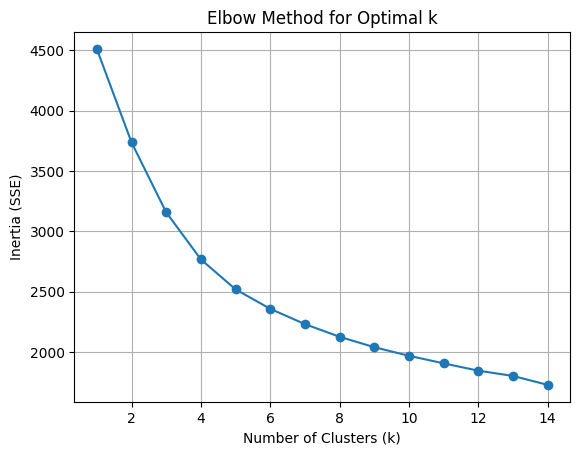

In [28]:
inertia = []
for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data[numerical_columns])
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.plot(range(1, 15), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()


# 7. Choose k, Apply KMeans Clustering 8. Assign Clusters to Data Points 9. Evaluate the Clustering

In [29]:
# choosing k from the Elbow Method
kmeans = KMeans(n_clusters=6, random_state=42)
y_pred = kmeans.fit_predict(data[numerical_columns])

# Add cluster labels to the dataset
df['cluster'] = y_pred

silhouette = silhouette_score(data[numerical_columns], y_pred)
print(f"Silhouette Score: {silhouette:.5f}")
print(f"Inertia (SSE): {kmeans.inertia_}")

Silhouette Score: 0.19689
Inertia (SSE): 2358.3249310388887


# 10. Visualize the Results

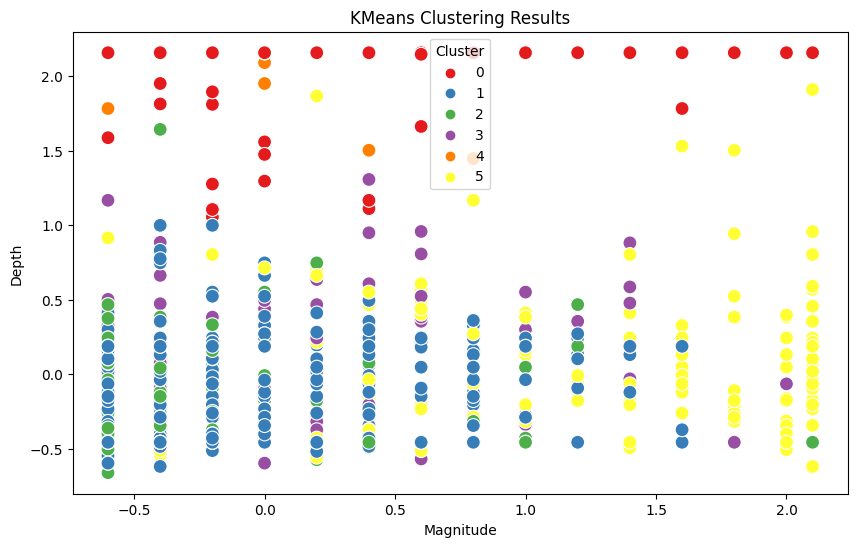

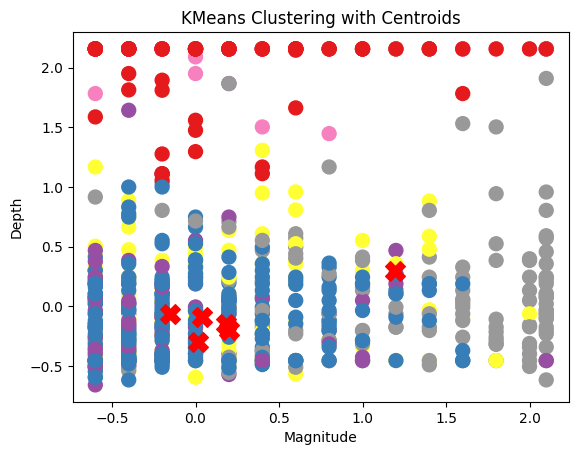

In [30]:
# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['magnitude'], y=data['depth'], hue=df['cluster'], palette='Set1', s=100)
plt.xlabel('Magnitude')
plt.ylabel('Depth')
plt.title('KMeans Clustering Results')
plt.legend(title='Cluster')
plt.show()

# plot the centroids 
centroids = kmeans.cluster_centers_
plt.scatter(data['magnitude'], data['depth'], c=df['cluster'], cmap='Set1', s=100)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', c='red', s=200)
plt.xlabel('Magnitude')
plt.ylabel('Depth')
plt.title('KMeans Clustering with Centroids')
plt.show()


# 11. Interpret Results

The KMeans clustering algorithm was applied with 6 clusters, and the following results were obtained:

Silhouette Score: 0.19689

The silhouette score is a measure of how similar each data point is to its own cluster compared to other clusters. 

A score closer to +1 indicates well-separated and distinct clusters, while a score closer to -1 suggests poor clustering. 

In this case, the score of 0.19689 is relatively low, indicating that the clusters are not well-separated. 

This suggests that the chosen number of clusters (6) may not be optimal: such as testing different values for k or experimenting with other clustering algorithms, may be necessary.

Inertia (SSE): 2358.3249310388887

Inertia, or the sum of squared errors (SSE), measures the compactness of the clusters. 

A lower inertia value indicates that the clusters are more compact and that the algorithm has done a better job of grouping similar data points together. 

The inertia value of 2358.32 suggests that the clustering results are not highly compact. 

# 12. Iterate and Improve: the results of KMeans clustering

In [31]:
# Perform KMeans clustering with k=6 
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10, init='k-means++')
y_pred = kmeans.fit_predict(data)

# Add cluster labels to the dataset
data['cluster'] = y_pred

# Calculate silhouette score
silhouette = silhouette_score(data, y_pred)
print(f"Silhouette Score: {silhouette:.2f}")

# Inertia (SSE)
print(f"Inertia (SSE): {kmeans.inertia_}")

Silhouette Score: 0.27
Inertia (SSE): 2719.990037842332
